# Notebook 05 — GDELT Analysis

## Purpose
Analyse the processed GDELT snapshot to understand:
1. **Which themes** dominate the 15-minute global news window
2. **What sentiment** (tone) is associated with each theme

This provides the **global context** that complements our historical ABC News analysis.

## Why Cross-Reference with GDELT?

| ABC News corpus | GDELT GKG |
|---|---|
| English-only headlines | 100+ languages, global |
| Historical (2003–2012) | Near real-time (15-min) |
| No sentiment labels | Tone score included |
| Free-text | Controlled theme vocabulary |

Combining both gives a **longitudinal + real-time** view of news trends.


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

sns.set_theme(style='whitegrid')

gdelt_path = 'data/gdelt_processed.csv'
if not os.path.exists(gdelt_path):
    print('[SKIP] gdelt_processed.csv not found — run Notebook 04 first.')
else:
    df = pd.read_csv(gdelt_path)
    df['theme_list'] = df['theme_list'].apply(ast.literal_eval)
    print(f'Loaded {len(df):,} GDELT records')
    display(df.head())

Loaded 564 GDELT records


,GKGRECORDID,DATE,SOURCECOMMONNAME,DOCUMENTIDENTIFIER,theme_list,tone_value
0,20260322044500-0,20260322044500,openpr.com,https://www.openpr.com/news/4434395/crypto-mar...,[EPU_ECONOMY_HISTORIC],0.000000
1,20260322044500-1,20260322044500,goodhousekeeping.com,https://www.goodhousekeeping.com/food-recipes/...,"[TAX_FOODSTAPLES_BREAD, TAX_FOODSTAPLES_BREAD,...",1.344364
2,20260322044500-2,20260322044500,krrvonline.com,https://krrvonline.com/entertainment/9b9e894cf...,"[TAX_FNCACT_OFFICIAL, EPU_CATS_REGULATION, TAX...",2.624672
3,20260322044500-3,20260322044500,townhall.com,https://townhall.com/columnists/marklewis/2026...,"[EPU_POLICY_POLITICAL, TAX_FOODSTAPLES_GRAIN, ...",0.948367
4,20260322044500-4,20260322044500,koreaherald.com,https://www.koreaherald.com/article/10699805,"[EPU_ECONOMY_HISTORIC, WB_1467_EDUCATION_FOR_A...",3.115265


## Top 15 GDELT Themes

Top 15 GDELT Themes:
  CRISISLEX_C07_SAFETY                       356
  CRISISLEX_CRISISLEXREC                     355
  USPEC_POLITICS_GENERAL1                    354
  GENERAL_GOVERNMENT                         354
  ARMEDCONFLICT                              301
  LEADER                                     297
  EPU_CATS_NATIONAL_SECURITY                 296
  TAX_FNCACT_MINISTER                        294
  EPU_POLICY_GOVERNMENT                      286
  MANMADE_DISASTER_IMPLIED                   268
  UNGP_FORESTS_RIVERS_OCEANS                 264
  WB_696_PUBLIC_SECTOR_MANAGEMENT            256
  TAX_ECON_PRICE                             216
  ENV_OIL                                    208
  WB_135_TRANSPORT                           207


/var/folders/bq/2ff4zcvx67x123ybfglrnlth0000gn/T/ipykernel_42901/3313960589.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Theme', data=theme_df, palette='viridis', ax=ax)


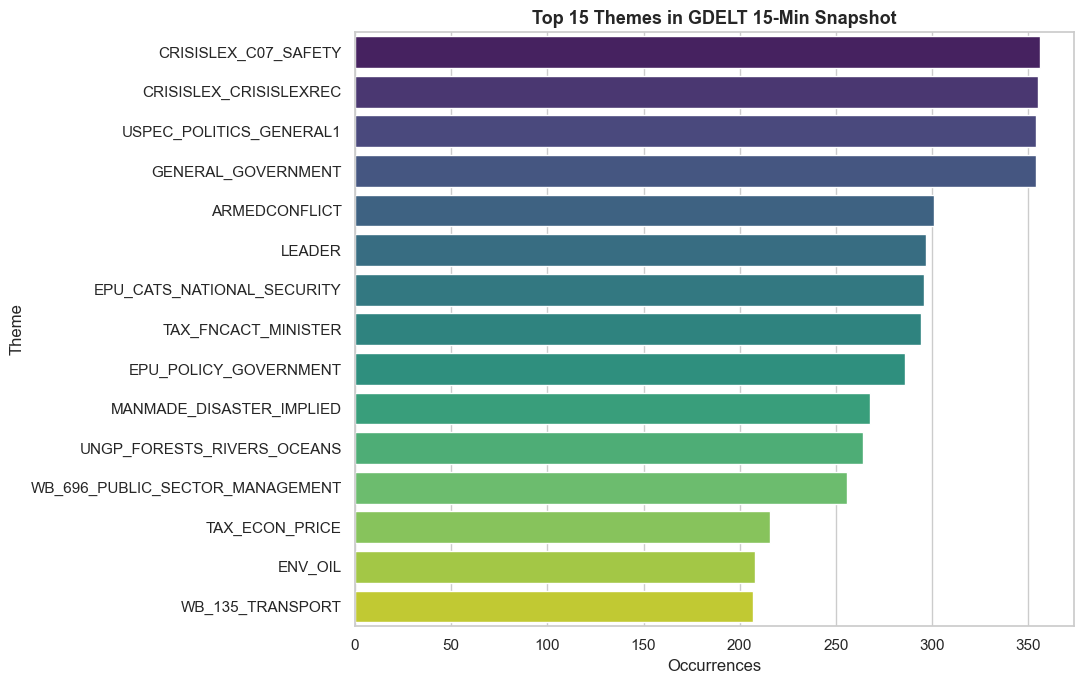

In [3]:
if 'df' in dir():
    all_themes = [t for sublist in df['theme_list'] for t in sublist]
    theme_counts = Counter(all_themes)
    top15 = theme_counts.most_common(15)
    print('Top 15 GDELT Themes:')
    for theme, count in top15:
        print(f'  {theme:<40} {count:>5}')

    theme_df = pd.DataFrame(top15, columns=['Theme', 'Count'])
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.barplot(x='Count', y='Theme', data=theme_df, palette='viridis', ax=ax)
    ax.set_title('Top 15 Themes in GDELT 15-Min Snapshot', fontsize=13, fontweight='bold')
    ax.set_xlabel('Occurrences')
    plt.tight_layout()
    plt.savefig('reports/gdelt_top_themes.png', dpi=150)
    plt.show()

## Average Tone (Sentiment) per Theme

,Theme,AvgTone
13,ENV_OIL,-5.227
4,ARMEDCONFLICT,-3.947
6,EPU_CATS_NATIONAL_SECURITY,-3.911
1,CRISISLEX_CRISISLEXREC,-3.622
12,TAX_ECON_PRICE,-3.113
0,CRISISLEX_C07_SAFETY,-2.861
5,LEADER,-2.761
14,WB_135_TRANSPORT,-2.582
3,GENERAL_GOVERNMENT,-2.304
9,MANMADE_DISASTER_IMPLIED,-2.215


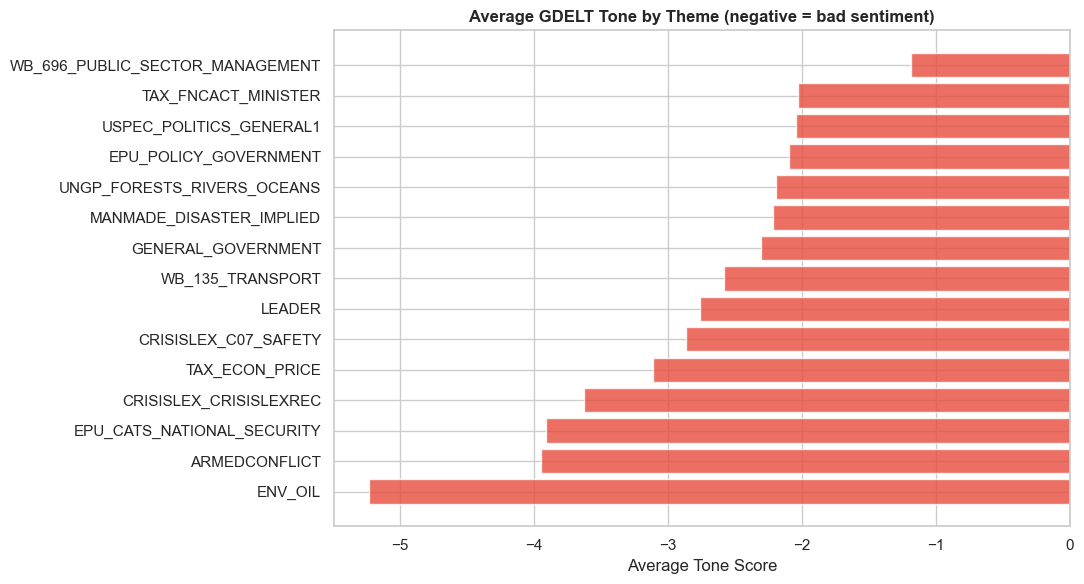

In [4]:
if 'df' in dir():
    top_names = [t[0] for t in top15]
    tone_data = []
    for theme in top_names:
        mask = df['theme_list'].apply(lambda l: theme in l)
        avg_tone = df.loc[mask, 'tone_value'].mean()
        tone_data.append({'Theme': theme, 'AvgTone': round(avg_tone, 3)})

    tone_df = pd.DataFrame(tone_data).sort_values('AvgTone')
    display(tone_df)

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#E74C3C' if t < 0 else '#27AE60' for t in tone_df['AvgTone']]
    ax.barh(tone_df['Theme'], tone_df['AvgTone'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Average GDELT Tone by Theme (negative = bad sentiment)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Average Tone Score')
    plt.tight_layout()
    plt.savefig('reports/gdelt_theme_tone.png', dpi=150)
    plt.show()

## Summary

GDELT analysis provides:
- **Theme frequency** — dominant global narratives in the snapshot window
- **Sentiment per theme** — positive/negative tone context for event scoring

These outputs feed directly into the **Event Impact Scoring** module (Notebook 06).